# Geometric Brownian Motion

**What this is:** Geometric Brownian motion is the reference process for equity prices
and the dynamics assumed by Black-Scholes. Modelling the log price as a drifting Brownian
motion keeps prices strictly positive, which in turn makes log returns normally
distributed with constant volatility.

**Why it matters:** Every other model in this repository is a response to one of those
assumptions failing, since Heston relaxes constant volatility, Merton adds
discontinuities, and Bachelier drops positivity altogether.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | initial asset price |
| $\mu$ | `mu` | drift, the expected rate of return |
| $\sigma$ | `sigma` | volatility, the standard deviation of log returns |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $\varepsilon_{i,j}$ | `epsilon` | independent standard normal shocks, $\varepsilon_{i,j} \sim \mathcal{N}(0,1)$ |

In [2]:
S0 = 100
mu = 0.03
sigma = 0.2
T = 1
n = 252
dt = T/n
num_paths = 100
epsilon = np.insert(np.random.normal(0,1,(n,num_paths)),0,0,axis=0)

## Model

**Continuous time:**

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t \quad \Longrightarrow \quad
S_t = S_0 \exp\!\left( \left( \mu - \tfrac{1}{2}\sigma^2 \right) t + \sigma W_t \right)$$

**Discrete time:** the closed form solution above is sampled directly, so this scheme is
exact rather than an Euler approximation and carries no discretisation bias.

$$S_{i,j} = S_0 \exp\!\left( \left( \mu - \tfrac{1}{2}\sigma^2 \right) i \, \Delta t
+ \sigma \sqrt{\Delta t} \sum_{m=1}^{i} \varepsilon_{m,j} \right)$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n]$ and
$j \in [1, \texttt{num\_paths}]$.

**In code:** $i \, \Delta t$ is `dt * np.arange(n + 1)[:, None]`, reshaped to a column
so it broadcasts across paths, and $\sum_{m=1}^{i} \varepsilon_{m,j}$ is
`np.cumsum(epsilon, axis=0)` with $\varepsilon_{0,j} = 0$. Arrays are stored as
`(n + 1, num_paths)` throughout the repository, so the array indexing matches the
$(i, j)$ ordering used above.

In [3]:
paths = S0 * np.exp((mu - 0.5 * sigma ** 2) * dt * np.arange(n + 1)[:, None] + sigma * np.sqrt(dt) * np.cumsum(epsilon,axis=0))

## Results

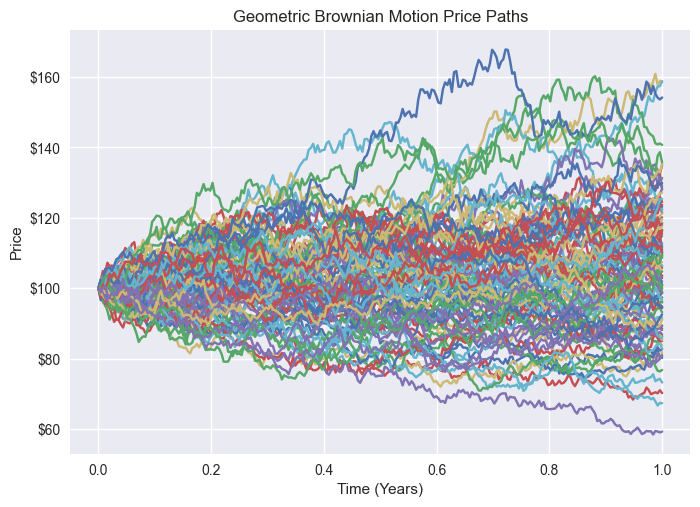

In [4]:
time_steps = np.linspace(0,T,n+1)
plt.plot(time_steps,paths)

plt.grid(True)
plt.xlabel("Time (Years)")
plt.ylabel("Price")
plt.title("Geometric Brownian Motion Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.show()